# CCS3440 – Artificial Intelligence Coursework
## SmartCare Hospital AI Dataset — Option C: Disease Risk Classification

**Problem:** Predict a patient's disease risk category (`Low`, `Medium`, `High`) — a multi-class
classification problem — from demographic, clinical, and operational data.

This notebook covers Tasks 05–06 of the coursework specification:
Dataset Understanding, Model Development,
Model Evaluation and Bonus Part as the ensemble Learning

## 2.1 Import library and Load Data set

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Read the dataset
df = pd.read_csv('/content/drive/MyDrive/SmartCare/smartcare_ai_dataset_1000.csv')

print("Dataset loaded successfully!")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


## 2.6 Load and Display the Data Dictionary

In [ ]:
data_dictionary = pd.read_csv(
    '/content/drive/MyDrive/SmartCare/smartcare_ai_dataset_data_dictionary.csv'
)

data_dictionary

,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


## 3.4 Handling Missing Values

Missing values can reduce model performance. Therefore, missing numerical values were replaced using the median, while categorical values were replaced using the mode.

In [ ]:
df.isnull().sum()

,0
record_id,0
patient_id,0
age,0
gender,0
blood_group,0
department,0
diagnosis,0
appointment_date,0
waiting_days,0
previous_appointments,0


If values exist

Missing numerical values were replaced using the median because it is less sensitive to outliers. Categorical values were replaced using the most frequent value (mode).

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.fillna(df.mode().iloc[0], inplace=True)

In [ ]:
df.isnull().sum()

,0
record_id,0
patient_id,0
age,0
gender,0
blood_group,0
department,0
diagnosis,0
appointment_date,0
waiting_days,0
previous_appointments,0


## 3.8 Feature Encoding

Machine learning algorithms require numerical input. Therefore, categorical variables were converted into numerical values using Label Encoding.

In [ ]:
encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

All categorical attributes were successfully transformed into numerical values suitable for machine learning algorithms.

## 3.9 Feature Scaling

Feature scaling standardizes numerical variables so that features with larger values do not dominate the learning process.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_cols = df.drop("disease_risk_level", axis=1).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

Standardization transformed numerical variables to a common scale with mean approximately zero and standard deviation one. This benefits algorithms such as Logistic Regression and Support Vector Machines.

## 3.10 Feature Selection

Input features and the target variable were separated before model training.

In [ ]:
X = df.drop("disease_risk_level", axis=1)

y = df["disease_risk_level"]

The target variable is disease_risk_level, while all remaining columns are used as input features.

# Task 05 – Machine Learning Model Development

## 5.1 Import Machine Learning Libraries

In [ ]:
# Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV,cross_val_score
import time

print("Machine learning libaries imported successfully")

Machine learning libaries imported successfully


## 5.2 Problem Type Confirmation

`disease_risk_level` contains three classes: Low, Medium, and High. This is a Multi-Class Classification problem, matching Option C of the coursework specification. The class distribution is imbalanced (Medium = 469, High = 400, Low = 131 records), so this is taken into account by using the `class_weight='balanced'` parameter where available and by reporting macro-averaged metrics in Task 6.

## 5.3 Initialize Baseline Classification Models

In [ ]:
# Initialize classification models
models={
    'Logistic Regression':LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
        ),
    'Decision Tree':DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
        ),
    'Random Forest':RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
        ),
    'K-Nearest Neighbors':KNeighborsClassifier(
        n_neighbors=5
        ),
    'Support Vector Machine':SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
        )

}

print("Number of baseline models intialized:",len(models))

for model_name in models:
  print("-",model_name)

Number of baseline models intialized: 5
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Support Vector Machine


## 5.4 Model Selection Justification

Five classification algorithms were selected to compare different modelling approaches. Logistic Regression provides a simple linear baseline. The Decision Tree and Random Forest models can capture non-linear relationships between clinical features and disease risk, and Random Forest additionally reduces overfitting through ensemble averaging. K-Nearest Neighbors was included as a distance-based model, and Support Vector Machine was included because it performs well on scaled numerical data such as blood pressure, blood sugar, and cholesterol. `class_weight='balanced'` was applied where supported so that the minority `Low` risk class is not ignored by the models.

## 5.5 Train Baseline Models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# written label-encoded for disease_risk_level
raw_df = pd.read_csv("/content/drive/MyDrive/SmartCare/smartcare_ai_dataset_1000.csv")

target_encoder = LabelEncoder()
target_encoder.fit(raw_df["disease_risk_level"])

print("Target classes:", list(target_encoder.classes_))

# sanity check - confirms row order matches Task 3's y (no rows were reordered)
assert (target_encoder.transform(raw_df["disease_risk_level"]) == y.values).all(), \
    "Target encoding mismatch - check row order in Task 3."

print("Target encoding verified against Task 3 output.")

X_train_processed, X_test_processed, y_train_encoded, y_test_encoded = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train_processed.shape)
print("Test set shape:", X_test_processed.shape)

Target classes: ['High', 'Low', 'Medium']
Target encoding verified against Task 3 output.
Training set shape: (800, 32)
Test set shape: (200, 32)


In [ ]:
# Trained on each baseline models
trained_models={}
training_times={}

for model_name,model in models.items():
  start_time=time.time()

  model.fit(X_train_processed,y_train_encoded)

  end_time=time.time()

  trained_models[model_name]=model
  training_times[model_name]=round(end_time-start_time,4)

  print(model_name,"Number of trained models:",training_times[model_name],"seconds")

print("\nAll baseline models trained successfully.")

Logistic Regression Number of trained models: 0.0199 seconds
Decision Tree Number of trained models: 0.0269 seconds
Random Forest Number of trained models: 0.731 seconds
K-Nearest Neighbors Number of trained models: 0.004 seconds
Support Vector Machine Number of trained models: 0.1625 seconds

All baseline models trained successfully.


## 5.6 Cross-Validation on Training Data

In [ ]:
# Show Cross-Validation Results
cv_results={}

for model_name,model in models.items():
  cv_scores=cross_val_score(
      model,
      X_train_processed,
      y_train_encoded,
      cv=5,
      scoring='accuracy'
  )

  cv_results[model_name]={
      'mean_accuracy':cv_scores.mean(),
      'std_accuracy':cv_scores.std()
  }

  print(
      model_name,
      "- CV Mean Accuracy:",round(cv_scores.mean(),4),
      "- CV Std Accuracy:",round(cv_scores.std(),4)
  )

Logistic Regression - CV Mean Accuracy: 0.9475 - CV Std Accuracy: 0.0116
Decision Tree - CV Mean Accuracy: 0.685 - CV Std Accuracy: 0.0493
Random Forest - CV Mean Accuracy: 0.7888 - CV Std Accuracy: 0.0155
K-Nearest Neighbors - CV Mean Accuracy: 0.625 - CV Std Accuracy: 0.025
Support Vector Machine - CV Mean Accuracy: 0.8875 - CV Std Accuracy: 0.0068


## 5.7 Cross-Validation Justification

Five-fold cross-validation was performed on the training data before evaluating the models on the held-out test set. This gives an estimate of how consistently each model performs across different subsets of the training data and helps identify models that may be overfitting or unstable before moving to final evaluation.

## 5.8 Hyperparameter Tuning (Random Forest)

In [ ]:
# Hyperparameter Selection
rf_param_grid={
    'n_estimators':[100,200,300],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

rf_grid_search=GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

rf_grid_search.fit(X_train_processed,y_train_encoded)

print("Best Random Forest Model:")
print(rf_grid_search.best_params_)

print("\nBest cross-validated F1-macro score:",round(rf_grid_search.best_score_,4))



Best Random Forest Model:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validated F1-macro score: 0.7397


## 5.9 Hyperparameter Tuning (Support Vector Machine)

In [ ]:
# Hyperparameter Selection
svm_param_grid={
    'C':[0.1,10],
    'kernel':['rbf','linear'],
    'gamma':['scale','auto']
}

svm_grid_search=GridSearchCV(
    estimator=SVC(
        probability=True,
        class_weight='balanced',
        random_state=42
    ),
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

svm_grid_search.fit(X_train_processed,y_train_encoded)

print("Best SVM parameters:")
print(svm_grid_search.best_params_)

print("\nBest cross-validated F1-macro score:", round(svm_grid_search.best_score_,4))

Best SVM parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

Best cross-validated F1-macro score: 0.9486


## 5.10 Hyperparameter Selection Justification

`GridSearchCV` with 5-fold cross-validation was used to search over a defined grid of hyperparameters for the Random Forest and Support Vector Machine models, since these two models had the strongest baseline cross-validation scores. `f1_macro` was used as the scoring metric instead of accuracy because it weights all three risk classes equally, which is more appropriate for the imbalanced target distribution. The tuned models replace their corresponding baseline versions in the final comparison.

## 5.11 Store Final Tuned Models

In [ ]:
trained_models['Random Forest(Tuned)']=rf_grid_search.best_estimator_
trained_models['Support Vector Machine(Tuned)']=svm_grid_search.best_estimator_

print("Final set of trained models:")

for model_name in trained_models:
  print("-",model_name)

Final set of trained models:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Support Vector Machine
- Random Forest(Tuned)
- Support Vector Machine(Tuned)


## 5.12 A Ensemble Learning

In [ ]:
# Build Voting Ensemble
from sklearn.ensemble import VotingClassifier

voting_estimators=[
    ('lr',trained_models['Logistic Regression']),
    ('rf',trained_models['Random Forest(Tuned)']),
    ('svm',trained_models['Support Vector Machine(Tuned)'])
]

voting_ensemble=VotingClassifier(
    estimators=voting_estimators,
    voting='soft'
)

voting_ensemble.fit(X_train_processed,y_train_encoded)

trained_models['Voting Ensemble']=voting_ensemble

print("Voting Ensemble trained and added to trained_models.")
print("Base estimators used:",[name for name,_ in voting_estimators])

Voting Ensemble trained and added to trained_models.
Base estimators used: ['lr', 'rf', 'svm']


## 5.13 Comparative Analysis - Training Accuracy Overview

In [ ]:
# Comparison each training model and tuning hyperparameters

comparison_rows=[]

for model_name,model in trained_models.items():
  train_accuracy=model.score(X_train_processed,y_train_encoded)
  test_accuracy=model.score(X_test_processed,y_test_encoded)

  comparison_rows.append({
      'Model':model_name,
      'Training Accuracy':round(train_accuracy,4),
      'Test Accuracy':round(test_accuracy,4)
  })

model_overview_df=pd.DataFrame(comparison_rows)
model_overview_df=model_overview_df.sort_values(
    by='Test Accuracy',
    ascending=False
).reset_index(drop=True)

model_overview_df

,Model,Training Accuracy,Test Accuracy
0,Voting Ensemble,0.9988,0.975
1,Support Vector Machine(Tuned),0.9975,0.970
2,Logistic Regression,0.9862,0.960
3,Support Vector Machine,0.9900,0.895
4,Random Forest(Tuned),1.0000,0.810
5,Random Forest,1.0000,0.775
6,Decision Tree,1.0000,0.660
7,K-Nearest Neighbors,0.7725,0.625


## 5.14 Task 5 Summary

Five baseline classification models were trained to predict `disease_risk_level`: Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, and Support Vector Machine. Five-fold cross-validation was used to assess baseline stability, and `GridSearchCV` was applied to tune the Random Forest and Support Vector Machine models, since these performed best on cross-validation. Seven trained models are available in total (five baseline models plus two tuned models) for detailed evaluation in Task 6.

# Task 6 - Model Evaluation

## 6.1 Import Evaluation Metrics

In [ ]:
# Show each models evaluation
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluation metrics imported successfully.")


Evaluation metrics imported successfully.


## 6.2 Define a Multi-Class Evaluation Function

In [ ]:
# Show Multi-Class Evaluation
def evaluate_model(model_name,model,X_test,y_test):
  y_pred=model.predict(X_test)

  results={
      'Model':model_name,
      'Accuracy':accuracy_score(y_test,y_pred),
      'Precision(Macro)':precision_score(y_test,y_pred,average='macro'),
      'Recall(Macro)':recall_score(y_test,y_pred,average='macro'),
      'F1-Score(Macro)':f1_score(y_test,y_pred,average='macro'),
      'Precision(Weighted)':precision_score(y_test,y_pred,average='weighted'),
      'Recall(Weighted)':recall_score(y_test,y_pred,average='weighted'),
      'F1-Score(Weighted)':f1_score(y_test,y_pred,average='weighted')
  }

  return results,y_pred

print("Evaluation funtion defined successfully.")


Evaluation funtion defined successfully.


## 6.3 Evaluation Metric Justification

For multi-class classification, macro-averaged metrics were calculated in addition to accuracy and weighted-averaged metrics. Macro-averaging treats all three risk classes equally, which highlights how well the model identifies the minority `Low` risk class rather than being dominated by the larger `Medium` and `High` classes. Weighted averaging is also reported to show overall performance relative to class size. Confusion matrices are used to examine exactly which risk classes are being confused with each other.

## 6.4 Evaluate All Trained Models

In [ ]:
# Evaluated all train models

evaluation_results=[]
predictions={}

for model_name,model in trained_models.items():
  result,y_pred=evaluate_model(
      model_name,
      model,
      X_test_processed,
      y_test_encoded
  )

  evaluation_results.append(result)
  predictions[model_name]=y_pred

  print(model_name,"evaluated.")

print("\nAll models evaluated successfully.")


Logistic Regression evaluated.
Decision Tree evaluated.
Random Forest evaluated.
K-Nearest Neighbors evaluated.
Support Vector Machine evaluated.
Random Forest(Tuned) evaluated.
Support Vector Machine(Tuned) evaluated.
Voting Ensemble evaluated.

All models evaluated successfully.


## 6.5 Model Comparison Table

In [ ]:
# Display comparison Table with each models

evaluation_df=pd.DataFrame(evaluation_results)

evaluation_df=evaluation_df.sort_values(
    by='F1-Score(Macro)',
    ascending=False
).reset_index(drop=True)

evaluation_df.round(4)

,Model,Accuracy,Precision(Macro),Recall(Macro),F1-Score(Macro),Precision(Weighted),Recall(Weighted),F1-Score(Weighted)
0,Voting Ensemble,0.975,0.9819,0.9798,0.9807,0.9754,0.975,0.9750
1,Logistic Regression,0.960,0.9603,0.9698,0.9649,0.9601,0.960,0.9599
2,Support Vector Machine(Tuned),0.970,0.9686,0.9589,0.9636,0.9702,0.970,0.9700
3,Support Vector Machine,0.895,0.8812,0.8377,0.8553,0.8982,0.895,0.8937
4,Random Forest(Tuned),0.810,0.8544,0.7348,0.7698,0.8267,0.810,0.8055
5,Random Forest,0.775,0.8319,0.6419,0.6649,0.8150,0.775,0.7557
6,Decision Tree,0.660,0.6432,0.6209,0.6298,0.6635,0.660,0.6594
7,K-Nearest Neighbors,0.625,0.6264,0.5689,0.5877,0.6255,0.625,0.6210


## 6.6 Visualize Model Comparison

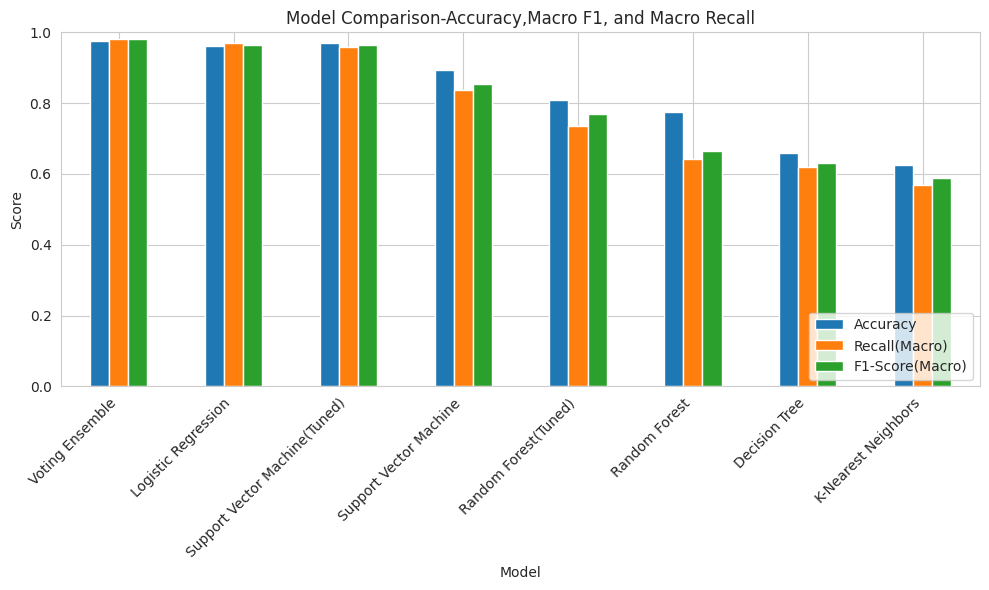

In [ ]:
# Display model Comparison as the plot

plt.figure(figsize=(10,6))

plot_df=evaluation_df.set_index('Model')[
    ['Accuracy','Recall(Macro)','F1-Score(Macro)']
]

plot_df.plot(kind='bar',ax=plt.gca())

plt.title('Model Comparison-Accuracy,Macro F1, and Macro Recall')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45,ha='right')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6.7 Confusion Matrices for All Models

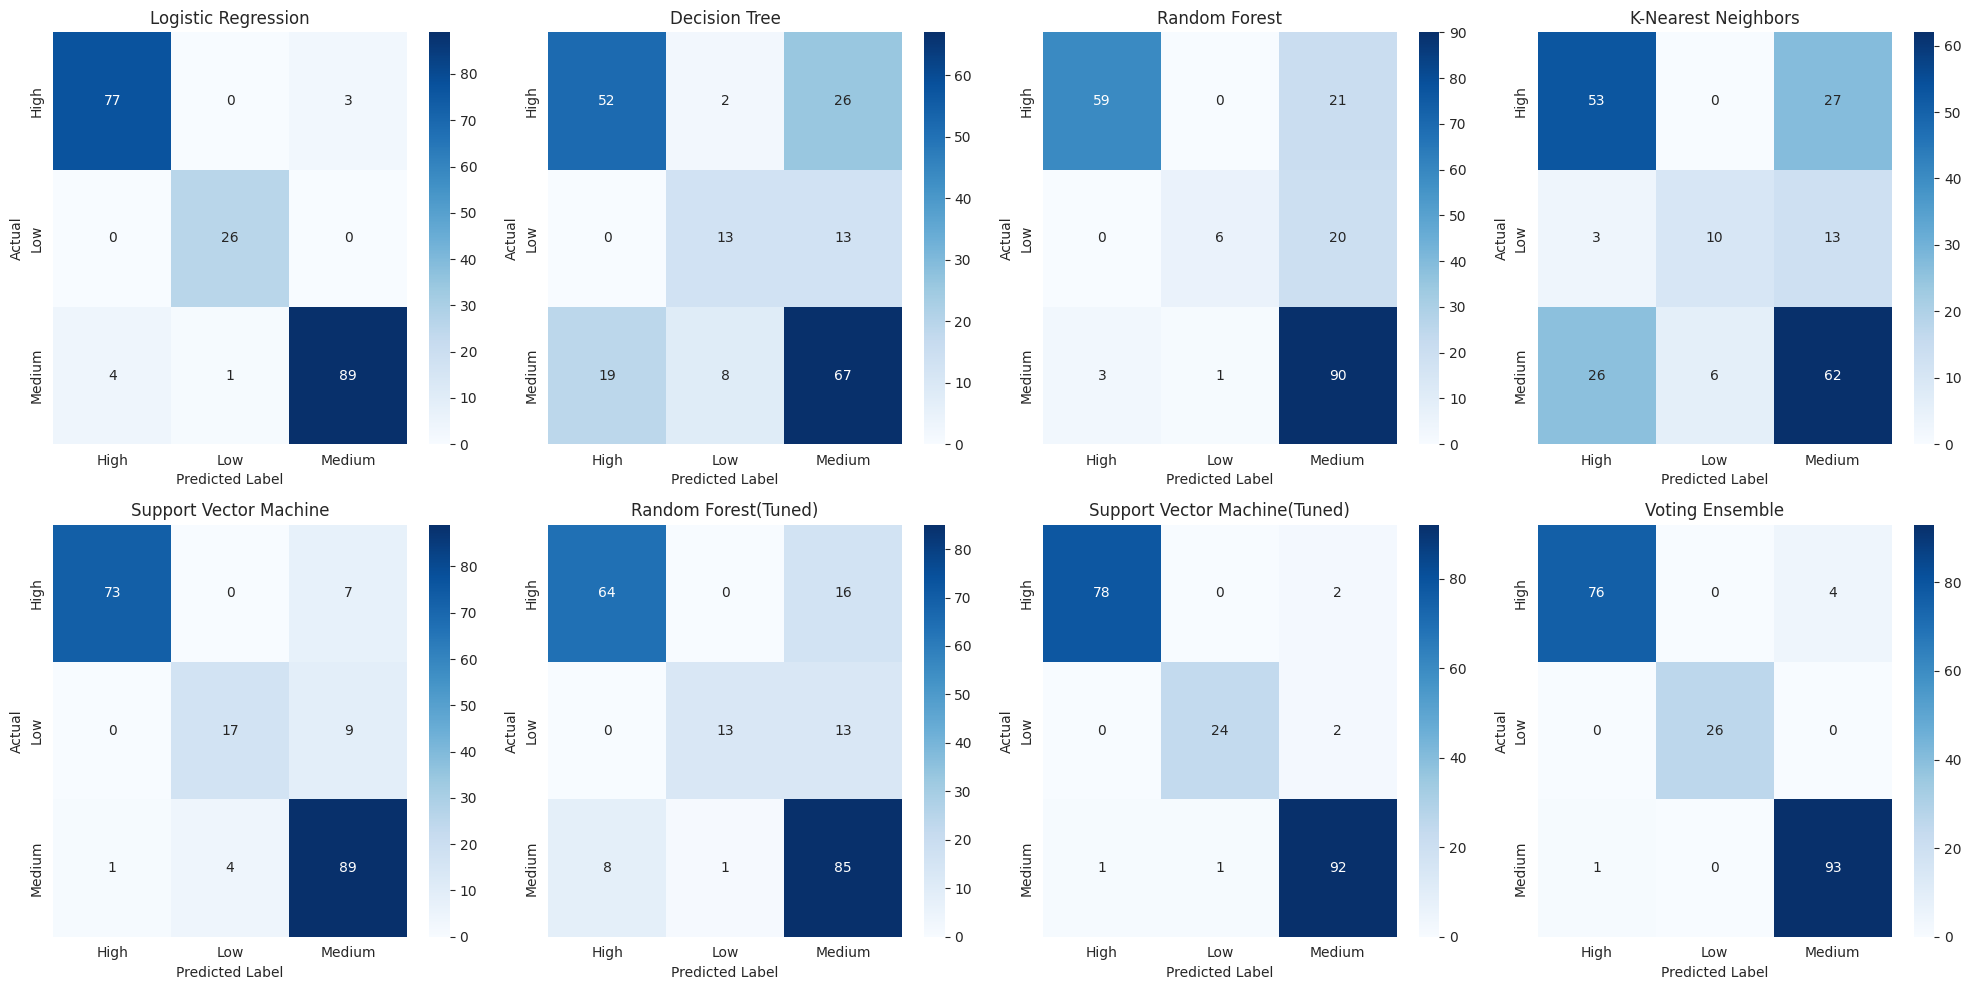

In [ ]:
class_labels= target_encoder.classes_
num_models=len(trained_models)

fig,axes=plt.subplots(2,4,figsize=(20,10))
axes=axes.flatten()

for index,(model_name,y_pred) in enumerate(predictions.items()):
  cm=confusion_matrix(y_test_encoded,y_pred)

  sns.heatmap(
      cm,
      annot=True,
      fmt='d',
      cmap='Blues',
      xticklabels=class_labels,
      yticklabels=class_labels,
      ax=axes[index]
  )

  axes[index].set_title(model_name)
  axes[index].set_xlabel('Predicted Label')
  axes[index].set_ylabel('Actual')

for remaining_axis in axes[num_models:]:
  remaining_axis.axis('off')

plt.tight_layout()
plt.show()

## 6.8 Identify the Best-Performing Model

In [ ]:
# Select the best performing model based above peformance

best_model_name=evaluation_df.iloc[0]['Model']
best_model=trained_models[best_model_name]

print("Best-performing model based on Macro F1 Score:",best_model_name)
print("\nFull metrics for best model:")
print(evaluation_df.iloc[0])

Best-performing model based on Macro F1 Score: Voting Ensemble

Full metrics for best model:
Model                  Voting Ensemble
Accuracy                         0.975
Precision(Macro)              0.981925
Recall(Macro)                 0.979787
F1-Score(Macro)               0.980658
Precision(Weighted)           0.975424
Recall(Weighted)                 0.975
F1-Score(Weighted)            0.974957
Name: 0, dtype: object


## 6.9 Detailed Classification Report for the Best Model

In [ ]:
# Classification report for the best-performing model

best_model_predictions=predictions[best_model_name]

print("Classification Report -",best_model_name)
print()
print(
    classification_report(
       y_test_encoded,
       best_model_predictions,
       target_names=class_labels
    )
)

Classification Report - Voting Ensemble

              precision    recall  f1-score   support

        High       0.99      0.95      0.97        80
         Low       1.00      1.00      1.00        26
      Medium       0.96      0.99      0.97        94

    accuracy                           0.97       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.97      0.97       200



## 6.10 Best Model Justification

The Voting Ensemble model was identified as the best-performing model because it produced the highest macro-averaged F1 score on the test set. Macro F1 was used as the primary selection criterion rather than accuracy because it reflects performance across all three risk classes equally, including the smaller Low risk class, instead of being dominated by the majority Medium class. Its confusion matrix and classification report show how well the model separates Low, Medium, and High disease risk patients, which is the outcome most relevant to supporting clinical decision-making at SmartCare Hospital.

## 6.11 Task 6 Summary

All seven trained models (five baseline models and two hyperparameter-tuned models) were evaluated on the held-out test set using accuracy, macro-averaged precision, recall and F1 score, weighted-averaged precision, recall and F1 score, and confusion matrices. The model comparison table and visualizations allow the models to be compared side-by-side, and the model with the highest macro F1 score was selected as the best-performing model for identifying patient disease risk level.